In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", "..", "..", ".."))  # go up three levels (from PauliSampling.jl\numerics\quantumboltzmannmachine\ceofficient_truncation to to PauliSampling.jl)

  Activating project at `~/Desktop/PauliSampling.jl`


In [2]:
# Load all packages
using PauliSampling, PauliPropagation, LinearAlgebra, Optim, ForwardDiff, Random, Statistics, JSON3, Dates, Printf, Plots, LaTeXStrings, DiffResults
using Base.Threads

# Dataset Generation (BAS)

In [3]:
function generate_bas_dataset(rows::Int, cols::Int)
    # Total qubits = rows * cols
    # BAS: Valid patterns are either all rows same (Stripes) or all cols same (Bars)
    valid_bitstrings = Vector{BitVector}()
    
    # 1. Stripes (Horizontal lines)
    # Each row can be all 0 or all 1. There are rows rows. 2^rows possibilities.
    for i in 0:(2^rows - 1)
        bs = BitVector(undef, rows * cols)
        bs_matrix = reshape(bs, (rows, cols)) # Julia is column-major, be careful with reshaping
        # We fill manually to be safe
        for r in 1:rows
            val = (i >> (r - 1)) & 1 == 1
            bs_matrix[r, :] .= val
        end
        push!(valid_bitstrings, vec(bs_matrix))
    end

    # 2. Bars (Vertical lines)
    # Each col can be all 0 or all 1. 2^cols possibilities.
    for i in 0:(2^cols - 1)
        bs = BitVector(undef, rows * cols)
        bs_matrix = reshape(bs, (rows, cols))
        for c in 1:cols
            val = (i >> (c - 1)) & 1 == 1
            bs_matrix[:, c] .= val
        end
        # Avoid duplicates (all zeros and all ones are in both sets)
        if bs ∉ valid_bitstrings
            push!(valid_bitstrings, vec(bs))
        end
    end
    
    return valid_bitstrings
end

function generate_standard_bas_with_probs(rows::Int, cols::Int)
    # 1. Get the bitstrings using the correct combinatorial logic
    valid_bitvectors = generate_bas_dataset(rows, cols)
    
    # 2. Convert BitVectors to Strings (for consistency)
    bitstrings = [join(Int.(bs)) for bs in valid_bitvectors]
    
    # 3. Create Uniform Probabilities
    N = length(bitstrings)
    probs = fill(1.0 / N, N)
    
    return bitstrings, probs
end

generate_standard_bas_with_probs (generic function with 1 method)

## Helpers

In [ ]:
# Helper to update H from a vector of coefficients
function update_paulistring_coeffs!(H, coeffs)
    @assert length(H) == length(coeffs)
    for i in 1:length(H)
        H[i] = PauliString(H[i].nqubits, H[i].term, coeffs[i])
    end
end

update_paulistring_coeffs! (generic function with 1 method)

### Negative Log-Likelihood cost function
$$L = -\frac{1}{|D|} \sum_{x \in D} \log P_{\theta}(x)$$

In [5]:
# 1. NLL Loss Function (Calculates Forward Pass)
# Returns: - (1/D) * Σ log P_theta(x)
function nll_loss_fun(coeffs, H_template, data_bitstrings, nq, num_layers, max_weight, min_abs_coeff)
    
    # 1. Update Hamiltonian with current coefficients
    H = deepcopy(H_template)
    update_paulistring_coeffs!(H, coeffs)

    # 2. Generate the Model Thermal State
    circuit, theta = paulistringtocircuit(H)
    rho = makethermalstate(nq, circuit, theta, num_layers;
                           max_weight=max_weight,
                           min_abs_coeff=min_abs_coeff,
                           optimize_for_z_basis=true,
                           max_sins=Inf)

    # 3. Calculate Mean Negative Log-Likelihood: - (1/D) * Σ log P(x)
    log_like = 0.0
    for x in data_bitstrings
        prob = PauliSampling.get_approx_prob(rho, x)
        log_like += log(max(prob, 1e-20))
    end
    
    return -log_like / length(data_bitstrings)
end

nll_loss_fun (generic function with 1 method)

# Training with Automatic Differentiation

In [6]:
# Gradient Function (Uses ForwardDiff AD)
function nll_grad_fun!(g, coeffs, H_template, data_bitstrings, nq, num_layers, max_weight, min_abs_coeff)
    
    # Define a closure that only depends on coeffs for ForwardDiff
    func_to_diff = (c) -> nll_loss_fun(c, H_template, data_bitstrings, nq, num_layers, max_weight, min_abs_coeff)
    
    # Compute gradient in-place
    ForwardDiff.gradient!(g, func_to_diff, coeffs)
end

nll_grad_fun! (generic function with 1 method)

In [10]:
#  Setup Parameters
nq = 8
rows, cols = 4, 2 # 3x2 grid for BAS dataset
@assert nq == rows * cols

rng = MersenneTwister(42)

# Generate Dataset
dataset = generate_bas_dataset(rows, cols)
println("Generated BAS dataset with $(length(dataset)) samples.")

# QBM Initialization (Hamiltonian Ansatz)
# lat_2d = SquareLattice(rows, cols)
lat_1d = ChainLattice(nq)
params_init = parameters(:heisenberg, nq; 
                         init=:random, 
                         coupling_vals=Dict(:XX => 0.5, :ZZ => 0.5, :YY => 0.5))
                         
# We want to learn the Hamiltonian coefficients that produce the distribution
qbm_H_paulis_template = makehamiltonian(params_init, lat_1d; connectivity=:alltoall, periodic=false)
initial_coeffs = [p.coeff for p in qbm_H_paulis_template]

num_layers_qbm = nq * 10
max_weight_qbm = nq
min_abs_coeff_qbm = 1e-6;

Generated BAS dataset with 18 samples.


In [11]:
# Optimization Loop 

# Logging
all_results = Dict()
timestamp = Dates.format(Dates.now(), "yyyymmdd_HHMMSS")
println("Starting NLL Optimization...")

opt = Optim.Options(
    iterations = 20,
    show_trace = true,
    allow_f_increases = false,
    store_trace = true,
    g_tol = 1e-4,
    f_tol = 1e-4
)

# Run Optimization
# We assume 'coeffs' are the variational parameters
result = optimize(
    c -> nll_loss_fun(c, qbm_H_paulis_template, dataset, nq, num_layers_qbm, max_weight_qbm, min_abs_coeff_qbm),
    (g, c) -> nll_grad_fun!(g, c, qbm_H_paulis_template, dataset, nq, num_layers_qbm, max_weight_qbm, min_abs_coeff_qbm),
    initial_coeffs,
    LBFGS(),
    opt
)

Starting NLL Optimization...
Iter     Function value   Gradient norm 
     0     6.133016e+00     8.026157e-01
 * time: 9.512901306152344e-5
     1     3.995350e+00     4.435586e-01
 * time: 41.85264205932617
     2     3.971265e+00     2.496044e-01
 * time: 72.79004216194153
     3     3.596555e+00     1.597240e-01
 * time: 118.51844620704651
     4     3.485700e+00     2.504655e-01
 * time: 149.3108081817627
     5     3.337510e+00     2.297150e-01
 * time: 196.17104315757751
     6     3.294522e+00     1.861764e-01
 * time: 227.66052103042603
     7     3.153868e+00     1.548233e-01
 * time: 275.49688720703125
     8     3.106534e+00     1.914126e-01
 * time: 307.0907211303711
     9     2.990322e+00     1.344158e-01
 * time: 354.5111210346222
    10     2.942141e+00     7.662573e-02
 * time: 401.6481671333313
    11     2.918675e+00     9.210167e-02
 * time: 448.5363931655884
    12     2.905986e+00     3.975857e-02
 * time: 494.7489411830902
    13     2.899356e+00     3.571996e-0

InterruptException: InterruptException:

In [ ]:
# Analysis & Plotting

final_coeffs = Optim.minimizer(result)
update_paulistring_coeffs!(qbm_H_paulis_template, final_coeffs)

# Re-create final state to check probabilities
circuit_final, theta_final = paulistringtocircuit(qbm_H_paulis_template)
rho_final = makethermalstate(nq, circuit_final, theta_final, num_layers_qbm; optimize_for_z_basis=true)

println("\nTop Generated Probabilities vs Dataset:")
# Check probabilities of all 2^n strings
all_probs = []
for i in 0:(2^nq - 1)
    bs = BitVector(digits(i, base=2, pad=nq))
    p = PauliSampling.approximate_prob(rho_final, bs)
    is_in_data = bs in dataset
    push!(all_probs, (i, p, is_in_data))
end

# Sort by probability
sort!(all_probs, by = x -> x[2], rev=true)

for (i, p, in_data) in all_probs[1:min(16, end)]
    marker = in_data ? "✅ DATA" : "❌"
    bs_str = string(i, base=2, pad=nq)
    @printf("String: %s | Prob: %.4f | %s\n", bs_str, p, marker)
end

# Plot Loss History
p1 = plot(Optim.f_trace(result), 
    title="Generative Modeling (NLL Loss)", 
    xlabel="Epoch", ylabel="NLL", 
    lw=2, label="BAS 2x2")
display(p1)

# Training with explicit Gradient computation

In a Fully Visible QBM, the gradient of the NLL loss function is given by the difference in expectation values:
$$\frac{\partial \text{NLL}}{\partial \theta_i} = \langle H_i \rangle_{\text{model}} - \langle H_i \rangle_{\text{data}}$$

In [12]:
# Calculates <H_i>_data = (1/D) * sum_x <x|H_i|x>
function precompute_data_expectations(H_template::Vector{PauliString}, dataset::Vector{String})
    println("📊 Pre-computing Data Expectations...")
    num_terms = length(H_template)
    data_expects = zeros(Float64, num_terms)
    
    nq = H_template[1].nqubits
    # Convert strings to BitVectors (assuming '1' char means bit is 1)
    # Ensure dataset strings are length nq
    data_bits = [BitVector([c == '1' for c in s]) for s in dataset]
    D = length(data_bits)

    for (i, pstr) in enumerate(H_template)
        # A. Off-Diagonal Terms (X, Y) -> Expectation is 0 for classical data
        if PauliPropagation.containsXorY(pstr.term)
            data_expects[i] = 0.0
            continue
        end

        # B. Diagonal Terms (Z, I) -> Calculate Average Parity
        sum_parity = 0.0
        
        # Identify active Z qubits in this term
        active_qubits = Int[]
        for q in 1:nq
            if PauliPropagation.getpauli(pstr.term, q) == 3 # Z=3
                push!(active_qubits, q)
            end
        end
        
        # Average over dataset
        for bs in data_bits
            ones_count = 0
            for q in active_qubits
                if bs[q]; ones_count += 1; end
            end
            # Expectation of Z is +1 for bit 0, -1 for bit 1. 
            # Product Z_i Z_j... is (-1)^(total 1s)
            sum_parity += (-1.0)^ones_count
        end
        
        data_expects[i] = sum_parity / D
    end
    
    return data_expects
end

precompute_data_expectations (generic function with 1 method)

In [13]:
# Gradient = <H>_data - <H>_model
function grad_fun_explicit!(g, coeffs, H_template, data_expects,
                            nq, num_layers, max_weight, min_abs_coeff)
    
    # 1. Update H
    update_paulistring_coeffs!(H_template, coeffs)
    
    # 2. Simulate Model State (Forward Pass)
    circuit, theta = paulistringtocircuit(H_template)
    
    # [CRITICAL] optimize_for_z_basis=false
    # We need the full quantum state to capture X/Y gradients properly!
    rho = makethermalstate(nq, circuit, theta, num_layers;
                           max_weight=max_weight,
                           min_abs_coeff=min_abs_coeff,
                           optimize_for_z_basis=false) 

    # 3. Compute Gradient via simple subtraction
    scale_factor = 2.0^nq # Normalization factor for Tr(rho P)

    for i in 1:length(H_template)
        # Get coefficient alpha from rho = sum alpha_i P_i
        alpha_P = real(PauliSampling.getcoeff(rho, H_template[i].term))
        model_expect = alpha_P * scale_factor
        
        # Explicit Formula
        g[i] = data_expects[i] - model_expect
    end
end

grad_fun_explicit! (generic function with 1 method)

In [14]:
#  Setup Parameters
nq = 8
rows, cols = 4, 2 # 3x2 grid for BAS dataset
@assert nq == rows * cols

rng = MersenneTwister(42)

# Generate Dataset
dataset = generate_bas_dataset(rows, cols)
bitstrings, probs = generate_standard_bas_with_probs(rows, cols)
# Pre-Compute Data Expectations 
data_expectations = precompute_data_expectations(qbm_H_paulis_template, bitstrings)

println("Generated BAS dataset with $(length(dataset)) samples.")

# QBM Initialization (Hamiltonian Ansatz)
# lat_2d = SquareLattice(rows, cols)
lat_1d = ChainLattice(nq)
params_init = parameters(:heisenberg, nq; 
                         init=:random, 
                         coupling_vals=Dict(:XX => 0.5, :ZZ => 0.5, :YY => 0.5))


                         
# We want to learn the Hamiltonian coefficients that produce the distribution
qbm_H_paulis_template = makehamiltonian(params_init, lat_1d; connectivity=:alltoall, periodic=false)
initial_coeffs = [p.coeff for p in qbm_H_paulis_template]

num_layers_qbm = nq * 10
max_weight_qbm = nq
min_abs_coeff_qbm = 1e-6;

📊 Pre-computing Data Expectations...
Generated BAS dataset with 18 samples.


In [15]:
# Optimize
opt = Optim.Options(
    iterations = 20,
    show_trace = true,
    allow_f_increases = false,
    store_trace = true,
    g_tol = 1e-4,
    f_tol = 1e-4,
)

# We pass closures directly to use the explicit functions
result_full = optimize(
    # Loss
    c -> nll_loss_fun(c, qbm_H_paulis_template, dataset, nq, num_layers_qbm, max_weight_qbm, min_abs_coeff_qbm),
    # Gradient (Explicit)
    (g, c) -> grad_fun_explicit!(
        g, c,
        qbm_H_paulis_template, data_expectations,
        nq, num_layers_qbm,
        max_weight_qbm, min_abs_coeff_qbm
    ),
    
    initial_coeffs,
    LBFGS(),
    opt
)

Iter     Function value   Gradient norm 
     0     6.133016e+00     8.499812e-01
 * time: 7.486343383789062e-5
     1     3.952438e+00     3.518067e-01
 * time: 8.054102897644043
     2     3.809402e+00     2.633109e-01
 * time: 16.0602970123291
     3     3.379056e+00     1.195203e-01
 * time: 20.951979875564575
     4     3.305238e+00     1.157471e-01
 * time: 23.07455587387085
     5     3.242038e+00     9.338322e-02
 * time: 24.97896385192871
     6     3.171062e+00     6.047581e-02
 * time: 27.20552086830139
     7     3.078862e+00     1.262317e-01
 * time: 29.466864824295044
     8     2.963805e+00     1.120788e-01
 * time: 36.44188904762268
     9     2.912045e+00     4.370236e-02
 * time: 42.26027202606201
    10     2.906329e+00     2.339936e-02
 * time: 44.572847843170166
    11     2.893850e+00     4.140490e-02
 * time: 51.310123920440674
    12     2.892056e+00     2.308641e-02
 * time: 54.23927283287048
    13     2.891377e+00     7.218874e-03
 * time: 58.27027893066406
 

 * Status: success

 * Candidate solution
    Final objective value:     2.890432e+00

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 4.26e-01 ≰ 0.0e+00
    |x - x'|/|x'|          = 6.91e-02 ≰ 0.0e+00
    |f(x) - f(x')|         = 3.62e-05 ≰ 0.0e+00
    |f(x) - f(x')|/|f(x')| = 1.25e-05 ≤ 1.0e-04
    |g(x)|                 = 4.19e-03 ≰ 1.0e-04

 * Work counters
    Seconds run:   75  (vs limit Inf)
    Iterations:    17
    f(x) calls:    48
    ∇f(x) calls:   48



Top Generated Probabilities vs Dataset:
String: 01000100 | Prob: 0.0560 | ✅ DATA
String: 10111011 | Prob: 0.0560 | ✅ DATA
String: 00100010 | Prob: 0.0559 | ✅ DATA
String: 11011101 | Prob: 0.0559 | ✅ DATA
String: 01100110 | Prob: 0.0558 | ✅ DATA
String: 10011001 | Prob: 0.0558 | ✅ DATA
String: 01010101 | Prob: 0.0557 | ✅ DATA
String: 10101010 | Prob: 0.0557 | ✅ DATA
String: 00110011 | Prob: 0.0556 | ✅ DATA
String: 11001100 | Prob: 0.0556 | ✅ DATA
String: 00001111 | Prob: 0.0556 | ✅ DATA
String: 11110000 | Prob: 0.0556 | ✅ DATA
String: 00010001 | Prob: 0.0553 | ✅ DATA
String: 11101110 | Prob: 0.0553 | ✅ DATA
String: 00000000 | Prob: 0.0551 | ✅ DATA
String: 11111111 | Prob: 0.0551 | ✅ DATA
String: 01110111 | Prob: 0.0549 | ✅ DATA
String: 10001000 | Prob: 0.0549 | ✅ DATA
String: 00011110 | Prob: 0.0000 | ❌
String: 11100001 | Prob: 0.0000 | ❌
String: 00101101 | Prob: 0.0000 | ❌
String: 11010010 | Prob: 0.0000 | ❌
String: 01001011 | Prob: 0.0000 | ❌
String: 10110100 | Prob: 0.0000 | ❌
Strin

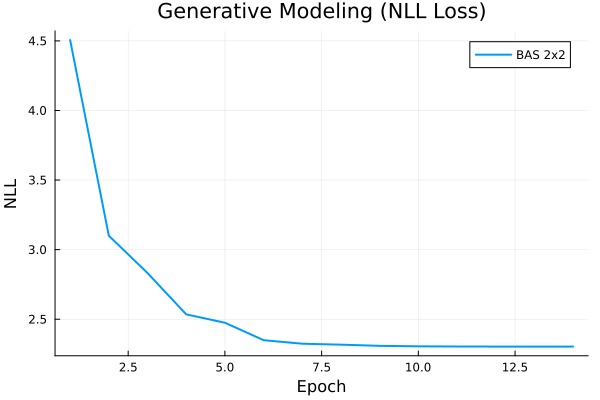

In [18]:
# Analysis & Plotting

final_coeffs = Optim.minimizer(result_full)
update_paulistring_coeffs!(qbm_H_paulis_template, final_coeffs)

# Re-create final state to check probabilities
circuit_final, theta_final = paulistringtocircuit(qbm_H_paulis_template)
rho_final = makethermalstate(nq, circuit_final, theta_final, num_layers_qbm; optimize_for_z_basis=true)

println("\nTop Generated Probabilities vs Dataset:")
# Check probabilities of all 2^n strings
all_probs = []
for i in 0:(2^nq - 1)
    bs = BitVector(digits(i, base=2, pad=nq))
    p = PauliSampling.approximate_prob(rho_final, bs)
    is_in_data = bs in dataset
    push!(all_probs, (i, p, is_in_data))
end

# Sort by probability
sort!(all_probs, by = x -> x[2], rev=true)

for (i, p, in_data) in all_probs[1:min(25, end)]
    marker = in_data ? "✅ DATA" : "❌"
    bs_str = string(i, base=2, pad=nq)
    @printf("String: %s | Prob: %.4f | %s\n", bs_str, p, marker)
end

# Plot Loss History
p1 = plot(Optim.f_trace(result), 
    title="Generative Modeling (NLL Loss)", 
    xlabel="Epoch", ylabel="NLL", 
    lw=2, label="BAS 2x2")
display(p1)